# Sesión 02 — Modelos de Clasificación
**Curso:** Ingeniería del Conocimiento (ISO56B)  
**Docente:** Msc. Jaime Antonio Huaytalla Pariona  
**Periodo:** 2026-II | Universidad Nacional del Centro del Perú  

---

## Objetivo
Implementar, comparar y analizar cuatro modelos fundamentales de clasificación supervisada — **Regresión Logística, Árbol de Decisión, SVM y KNN** — sobre el dataset **Coffee Quality and Pricing Benchmark** de Kaggle, evaluando sus fortalezas, limitaciones y sensibilidad al preprocesamiento.

## 1. Configuración del entorno

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob, os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    accuracy_score, f1_score
)
from sklearn.inspection import DecisionBoundaryDisplay

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Carga y comprensión del dataset

Utilizamos el **Coffee Quality and Pricing Benchmark** de Kaggle. Cada registro es un lote de café con variables de finca (país, altitud, clima), procesamiento y almacenamiento, y una evaluación de calidad: un puntaje continuo (60–94) y un grado de calidad de 5 niveles (`Commercial`, `Good`, `Very Good`, `Excellent`, `Exceptional`).

Para construir un problema de **clasificación binaria**, definimos:
- **Clase 1 (Alta):** grado ≥ Very Good (`Very Good`, `Excellent`, `Exceptional`)
- **Clase 0 (Estándar):** grado `Good` o `Commercial`

Esta binarización genera un problema **casi balanceado** (~60/40).

**Ajustes propios de este dataset:**
- Se conservan solo los registros `Original` (se descartan duplicados exactos y revisiones de medición).
- Solo se usan las variables que el diccionario del dataset permite para predecir calidad (`feature_dictionary.csv`), evitando fuga de información (puntajes sensoriales, precio, etc.).
- Se trabaja con una **muestra estratificada de 6000 lotes** para que SVM y KNN corran en un tiempo razonable.

In [9]:
def leer_csv(nombre, carpeta=None):
    if carpeta is not None:
        rutas = glob.glob(os.path.join(carpeta, '**', nombre), recursive=True)
        if rutas:
            return pd.read_csv(rutas[0])
    return pd.read_csv(nombre)

try:
    import kagglehub
    carpeta = kagglehub.dataset_download('razanihababdellatif/coffee-quality-and-pricing-benchmark')
    print(f'Dataset descargado en: {carpeta}')
except Exception as e:
    carpeta = None
    print(f'No se pudo descargar desde Kaggle: {e}')
    print('Usando los CSV locales ...')

df_raw = leer_csv('coffee_value_benchmark.csv', carpeta)
meta = leer_csv('coffee_record_metadata.csv', carpeta)
dic = leer_csv('feature_dictionary.csv', carpeta)

print(f'Dataset cargado: {df_raw.shape[0]} registros, {df_raw.shape[1]} columnas')
df_raw.head()

Dataset descargado en: C:\Users\ANTONY\.cache\kagglehub\datasets\razanihababdellatif\coffee-quality-and-pricing-benchmark\versions\1
Dataset cargado: 35700 registros, 36 columnas


,record_id,lot_id,harvest_season,harvest_calendar_year,harvest_month,country_of_origin,farm_type,farm_size_hectares,tree_age_years,altitude_mean_meters,...,lot_size_kg,roast_level,acidity_score,sweetness_score,body_score,aroma_score,flavor_score,coffee_quality_score,quality_grade,price_usd_per_kg
0,REC-0000001,LOT-0032936,2020/21,2020,10,Vietnam,Smallholder,0.58,28.0,1961.0,...,26433.0,Medium,7.95,7.30,8.45,7.35,7.37,78.01,Very Good,2.43
1,REC-0000002,LOT-0030952,2021/22,2022,1,Honduras,Smallholder,1.12,2.0,1257.0,...,25446.0,Medium,7.62,8.17,7.45,7.80,6.88,75.62,Good,4.06
2,REC-0000003,LOT-0018572,2020/21,2020,11,Vietnam,Cooperative,13.82,5.0,557.0,...,15707.0,Medium,8.47,8.83,8.13,7.70,8.10,72.41,Commercial,4.26
3,REC-0000004,LOT-0005318,2021/22,2021,10,Vietnam,Cooperative,9.96,22.0,652.0,...,2879.0,Medium,7.54,8.12,8.21,7.77,7.13,75.67,Good,3.60
4,REC-0000005,LOT-0006317,2021/22,2021,7,Brazil,Smallholder,1.90,11.0,971.0,...,9561.0,Medium,6.70,8.08,8.68,7.38,7.16,73.77,Good,4.16


In [10]:
df = df_raw.merge(meta[['record_id', 'record_type']], on='record_id')
df = df[df['record_type'] == 'Original'].drop(columns='record_type')
print(f'Registros originales: {df.shape[0]}')

# Muestra estratificada por grado de calidad
SAMPLE_SIZE = 6000
df = (df.groupby('quality_grade', group_keys=False)
        .sample(frac=SAMPLE_SIZE / len(df), random_state=RANDOM_STATE)
        .reset_index(drop=True))
print(f'Registros en la muestra de trabajo: {df.shape[0]}')
df.head()

Registros originales: 35000
Registros en la muestra de trabajo: 6000


,record_id,lot_id,harvest_season,harvest_calendar_year,harvest_month,country_of_origin,farm_type,farm_size_hectares,tree_age_years,altitude_mean_meters,...,lot_size_kg,roast_level,acidity_score,sweetness_score,body_score,aroma_score,flavor_score,coffee_quality_score,quality_grade,price_usd_per_kg
0,REC-0033159,LOT-0034965,2023/24,2023,10,Vietnam,Estate,81.65,10.0,150.0,...,6032.0,Medium,7.10,7.61,7.54,6.41,6.00,70.04,Commercial,4.98
1,REC-0015223,LOT-0000744,2021/22,2021,11,Kenya,Cooperative,12.23,18.0,967.0,...,27537.0,Dark,6.69,7.01,8.82,7.19,7.17,68.70,Commercial,6.15
2,REC-0010401,LOT-0013264,2021/22,2021,9,Indonesia,Smallholder,2.41,12.0,150.0,...,25927.0,Dark,7.22,7.35,8.77,7.59,7.54,72.44,Commercial,3.12
3,REC-0001281,LOT-0017798,2022/23,2022,11,Vietnam,Smallholder,1.86,13.0,757.0,...,29556.0,Dark,6.33,7.82,9.07,7.00,6.81,72.02,Commercial,3.98
4,REC-0022366,LOT-0030060,2020/21,2020,7,Indonesia,Smallholder,2.10,15.0,519.0,...,19975.0,Dark,7.30,7.30,8.94,6.96,7.21,69.06,Commercial,2.81


Distribución de calidad original:
quality_grade
Commercial     1200
Good           1200
Very Good      2100
Excellent      1200
Exceptional     300
Name: count, dtype: int64


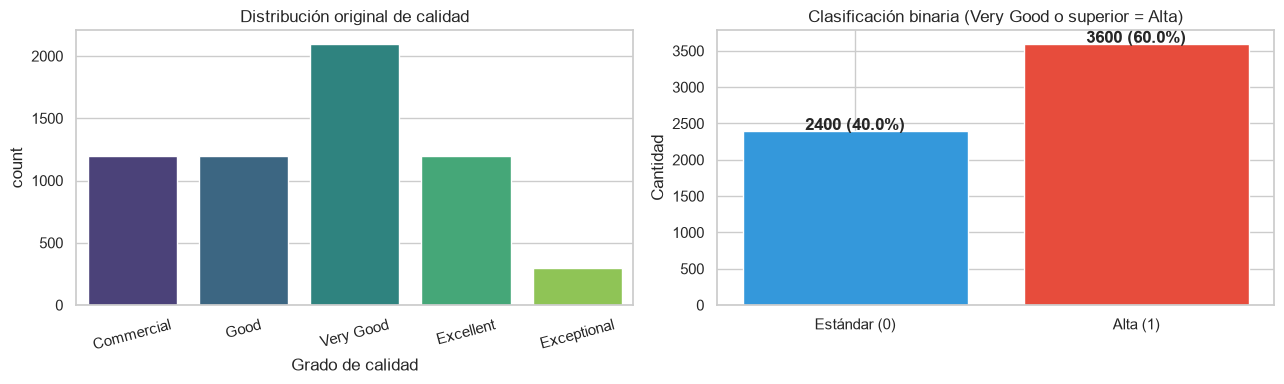


Ratio de balance: 1.5:1 (Alta vs Estándar)


In [11]:
# Distribución original de la variable 'quality_grade'
orden = ['Commercial', 'Good', 'Very Good', 'Excellent', 'Exceptional']
print('Distribución de calidad original:')
print(df['quality_grade'].value_counts().reindex(orden))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma original
sns.countplot(data=df, x='quality_grade', order=orden, ax=axes[0], palette='viridis')
axes[0].set_title('Distribución original de calidad')
axes[0].set_xlabel('Grado de calidad')
axes[0].tick_params(axis='x', rotation=15)

# Binarización
df['quality_label'] = df['quality_grade'].isin(['Very Good', 'Excellent', 'Exceptional']).astype(int)

counts = df['quality_label'].value_counts().sort_index()
axes[1].bar(['Estándar (0)', 'Alta (1)'], counts.values,
            color=['#3498db', '#e74c3c'])
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 10, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[1].set_title('Clasificación binaria (Very Good o superior = Alta)')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

print(f'\nRatio de balance: {counts[1]/counts[0]:.1f}:1 (Alta vs Estándar)')

---
## 3. Análisis exploratorio orientado a clasificación

In [12]:
# 3.1  Estadísticas descriptivas por clase
# Variables permitidas para predecir calidad (según feature_dictionary.csv)
features_validas = dic.loc[dic['usable_as_feature_for_quality'] == True, 'column'].tolist()
num_features = [c for c in features_validas if pd.api.types.is_numeric_dtype(df[c])]
cat_features = [c for c in features_validas if c not in num_features]
print(f'Features numéricas: {len(num_features)}  |  categóricas: {len(cat_features)}')

comparison = df.groupby('quality_label')[num_features].mean().T
comparison.columns = ['Estándar (0)', 'Alta (1)']
comparison['Diferencia %'] = ((comparison['Alta (1)'] - comparison['Estándar (0)']) / comparison['Estándar (0)'] * 100).round(1)
comparison.style.background_gradient(subset=['Diferencia %'], cmap='RdYlGn')

Features numéricas: 14  |  categóricas: 7


,Estándar (0),Alta (1),Diferencia %
harvest_calendar_year,2021.425000,2021.503611,0.000000
harvest_month,8.084167,8.126111,0.500000
farm_size_hectares,16.960200,16.130739,-4.900000
tree_age_years,15.292500,15.264167,-0.200000
altitude_mean_meters,716.010000,1432.270278,100.000000
avg_temp_c,21.718500,15.808139,-27.200000
avg_annual_rainfall_mm,1985.418878,1821.880820,-8.200000
humidity_pct,76.496039,73.214034,-4.300000
drying_duration_days,14.004208,14.460250,3.300000
storage_months,4.014167,3.951944,-1.600000


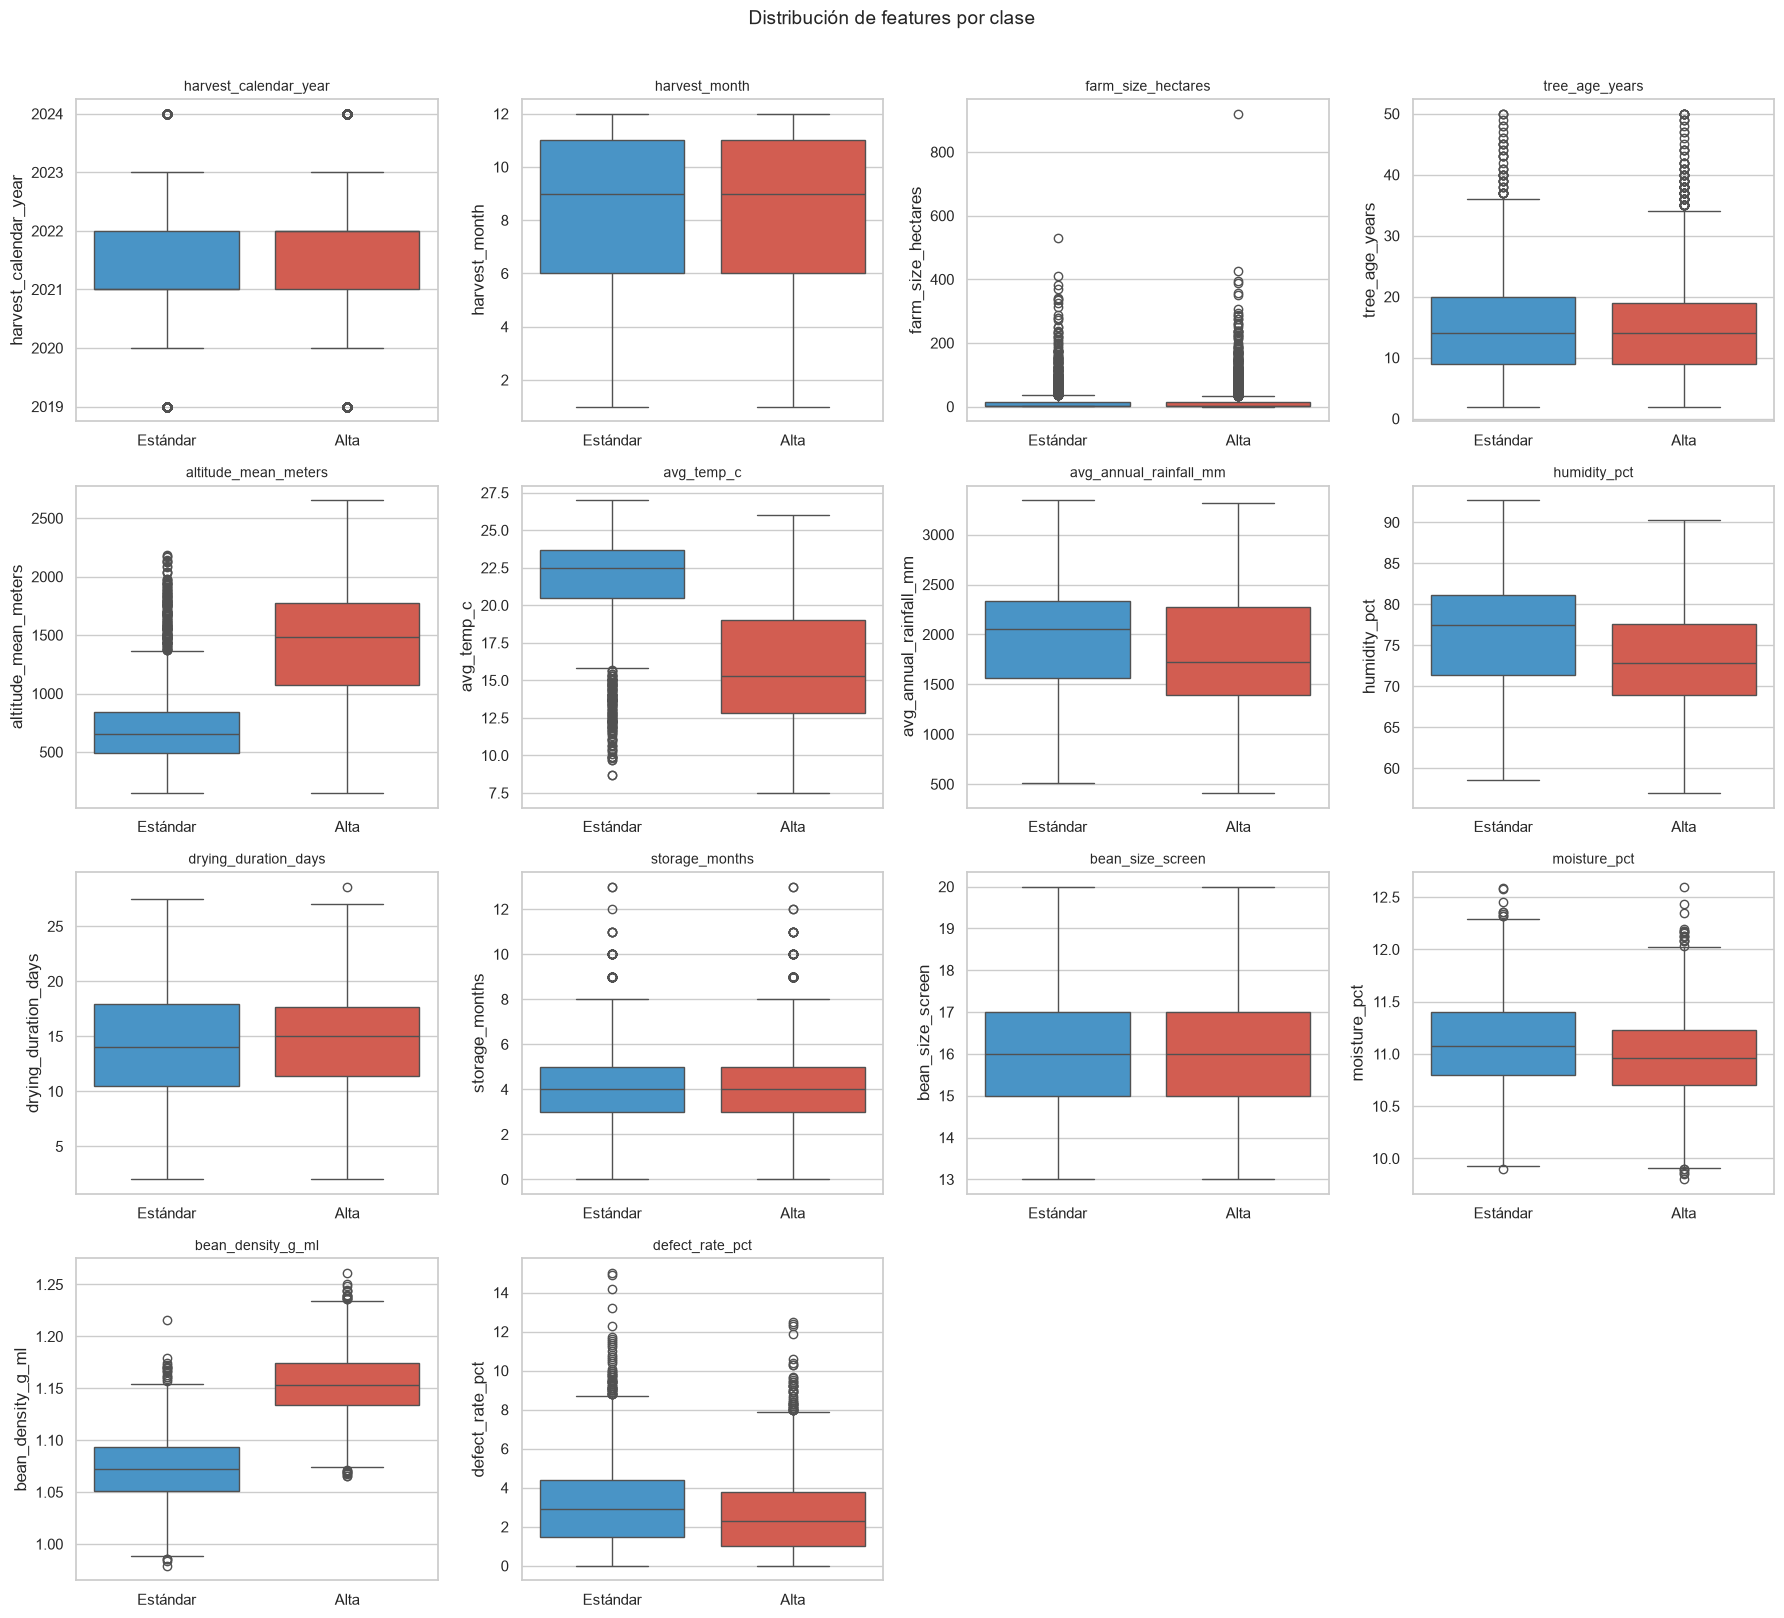

In [13]:
# 3.2  Distribución de features por clase (boxplots)
n_cols = 4
n_rows = int(np.ceil(len(num_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(data=df, x='quality_label', y=col, ax=axes[i],
                palette=['#3498db', '#e74c3c'], hue='quality_label', legend=False)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['Estándar', 'Alta'])

# Ocultar subplots vacíos
for j in range(len(num_features), len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Distribución de features por clase', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

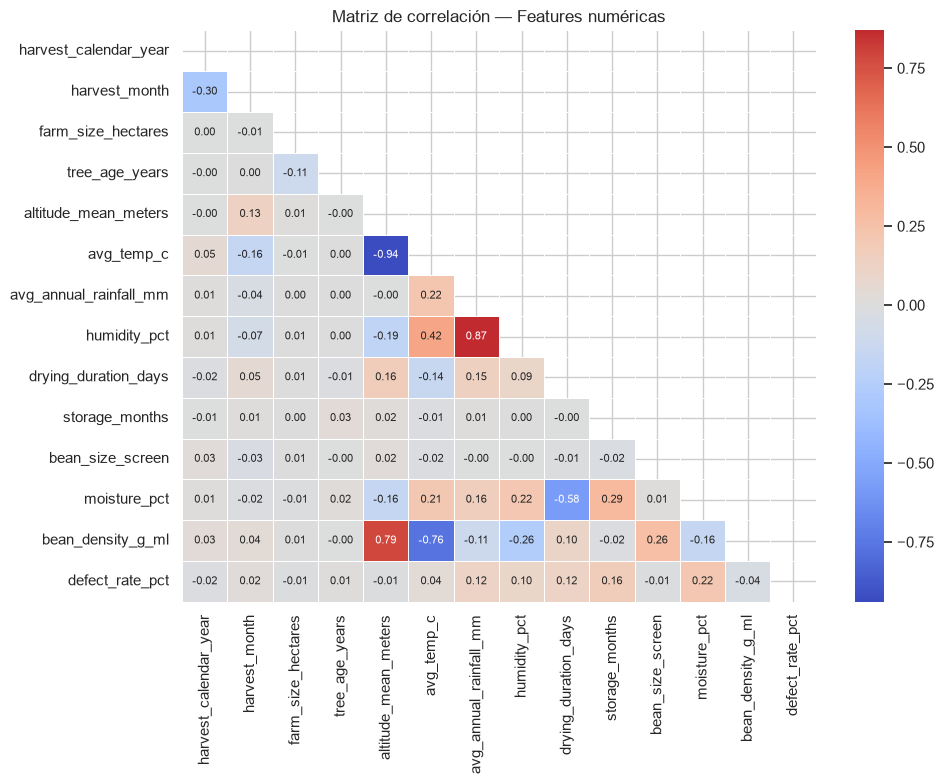

In [14]:
# 3.3  Correlación entre features
plt.figure(figsize=(10, 8))
corr = df[num_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Matriz de correlación — Features numéricas')
plt.tight_layout()
plt.show()

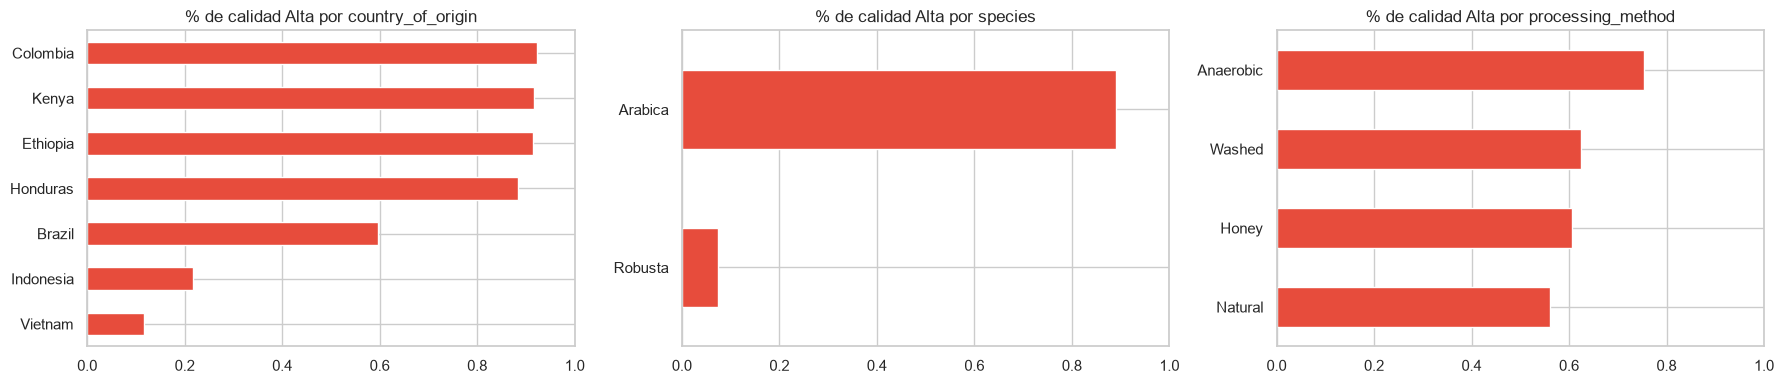

In [15]:
# 3.4  Proporción de calidad Alta por variable categórica
cat_clave = ['country_of_origin', 'species', 'processing_method']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, cat_clave):
    df.groupby(col)['quality_label'].mean().sort_values().plot(kind='barh', ax=ax, color='#e74c3c')
    ax.set_title(f'% de calidad Alta por {col}')
    ax.set_xlim(0, 1)
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

---
## 4. Preparación de datos

In [16]:
# 4.1  Separación features / target
# Las variables categóricas se convierten en columnas 0/1 (one-hot)
X = pd.get_dummies(df[features_validas], columns=cat_features, drop_first=True, dtype=float)
features = X.columns
y = df['quality_label'].copy()
print(f'Features tras la codificación: {X.shape[1]} ({len(num_features)} numéricas + {X.shape[1] - len(num_features)} one-hot)')

# 4.2  Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras  |  Test: {X_test.shape[0]} muestras')
print(f'Proporción clase 1 en train: {y_train.mean():.3f}')
print(f'Proporción clase 1 en test:  {y_test.mean():.3f}')

Features tras la codificación: 33 (14 numéricas + 19 one-hot)
Train: 4800 muestras  |  Test: 1200 muestras
Proporción clase 1 en train: 0.600
Proporción clase 1 en test:  0.600


In [17]:
# 4.3  Verificación de escalas (justifica la estandarización)
print('Rangos de las features numéricas (train):')
print('='*50)
for col in num_features:
    mn, mx = X_train[col].min(), X_train[col].max()
    print(f'{col:30s}  [{mn:10.2f}, {mx:10.2f}]  rango: {mx-mn:.2f}')

print('\n→ Las escalas difieren significativamente entre features.')
print('  Esto afecta directamente a SVM y KNN (basados en distancias).')
print('  Logistic Regression también se beneficia de la estandarización.')

# Valores faltantes (se imputan con la mediana dentro de cada pipeline)
faltantes = X_train.isnull().sum()
print('\nColumnas con valores faltantes en train:')
print(faltantes[faltantes > 0])

Rangos de las features numéricas (train):
harvest_calendar_year           [   2019.00,    2024.00]  rango: 5.00
harvest_month                   [      1.00,      12.00]  rango: 11.00
farm_size_hectares              [      0.52,     528.93]  rango: 528.41
tree_age_years                  [      2.00,      50.00]  rango: 48.00
altitude_mean_meters            [    150.00,    2654.00]  rango: 2504.00
avg_temp_c                      [      7.70,      27.00]  rango: 19.30
avg_annual_rainfall_mm          [    412.00,    3345.00]  rango: 2933.00
humidity_pct                    [     57.00,      92.70]  rango: 35.70
drying_duration_days            [      2.00,      27.30]  rango: 25.30
storage_months                  [      0.00,      13.00]  rango: 13.00
bean_size_screen                [     13.00,      20.00]  rango: 7.00
moisture_pct                    [      9.80,      12.60]  rango: 2.80
bean_density_g_ml               [      0.98,       1.26]  rango: 0.28
defect_rate_pct                 [ 

---
## 5. Modelo 1 — Regresión Logística

**Fundamento:** Modelo lineal que estima la probabilidad de pertenencia a una clase mediante la función sigmoide. Ideal como **baseline** por su interpretabilidad y eficiencia.

In [18]:
# 5.1  Pipeline con imputación y estandarización
pipe_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                               class_weight='balanced'))  # Compensar desbalance
])

# Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores_lr = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='f1')
print(f'Logistic Regression — F1 CV: {scores_lr.mean():.4f} ± {scores_lr.std():.4f}')

# Entrenamiento final
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

Logistic Regression — F1 CV: 0.9279 ± 0.0066


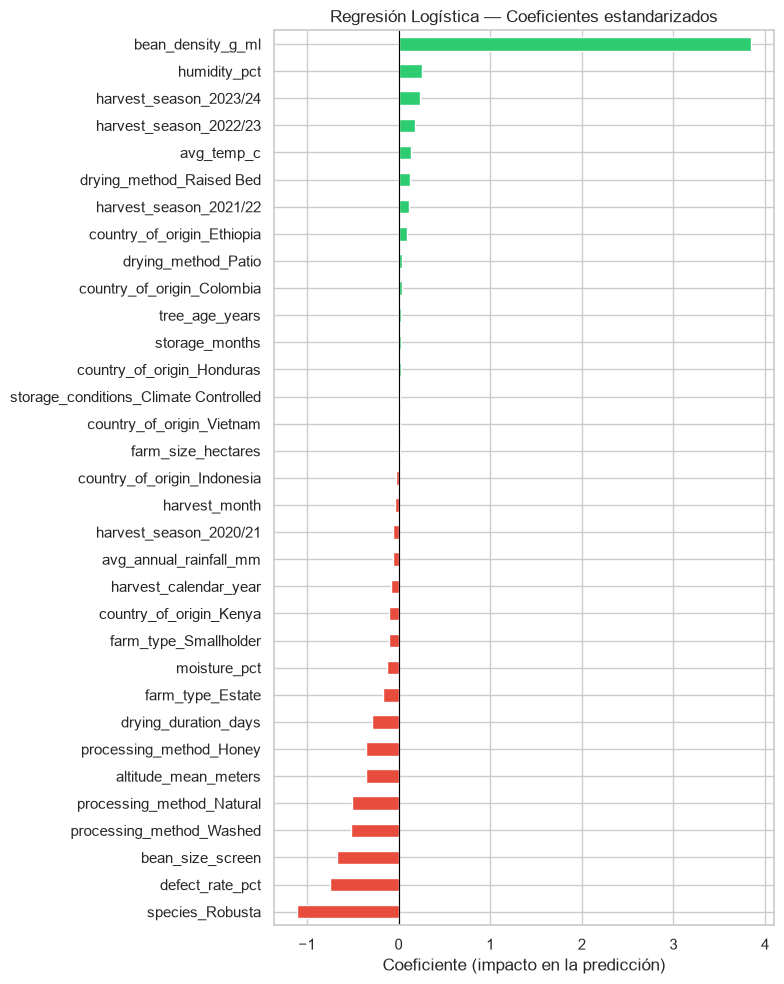


Interpretación: Un coeficiente positivo alto indica que valores mayores
de esa feature incrementan la probabilidad de clasificar como "Alta".


In [19]:
# 5.2  Coeficientes del modelo (interpretabilidad)
coefs = pd.Series(
    pipe_lr.named_steps['clf'].coef_[0],
    index=features
).sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs.values]
coefs.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Regresión Logística — Coeficientes estandarizados')
ax.set_xlabel('Coeficiente (impacto en la predicción)')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('\nInterpretación: Un coeficiente positivo alto indica que valores mayores')
print('de esa feature incrementan la probabilidad de clasificar como "Alta".')

---
## 6. Modelo 2 — Árbol de Decisión

**Fundamento:** Modelo no lineal que particiona el espacio de features mediante reglas if-else jerárquicas. Altamente interpretable, pero propenso al sobreajuste si no se controla la profundidad.

In [20]:
# 6.1  Pipeline (solo imputación; no requiere estandarización)
pipe_dt = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE
    ))
])

scores_dt = cross_val_score(pipe_dt, X_train, y_train, cv=cv, scoring='f1')
print(f'Decision Tree — F1 CV: {scores_dt.mean():.4f} ± {scores_dt.std():.4f}')

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

Decision Tree — F1 CV: 0.9248 ± 0.0054


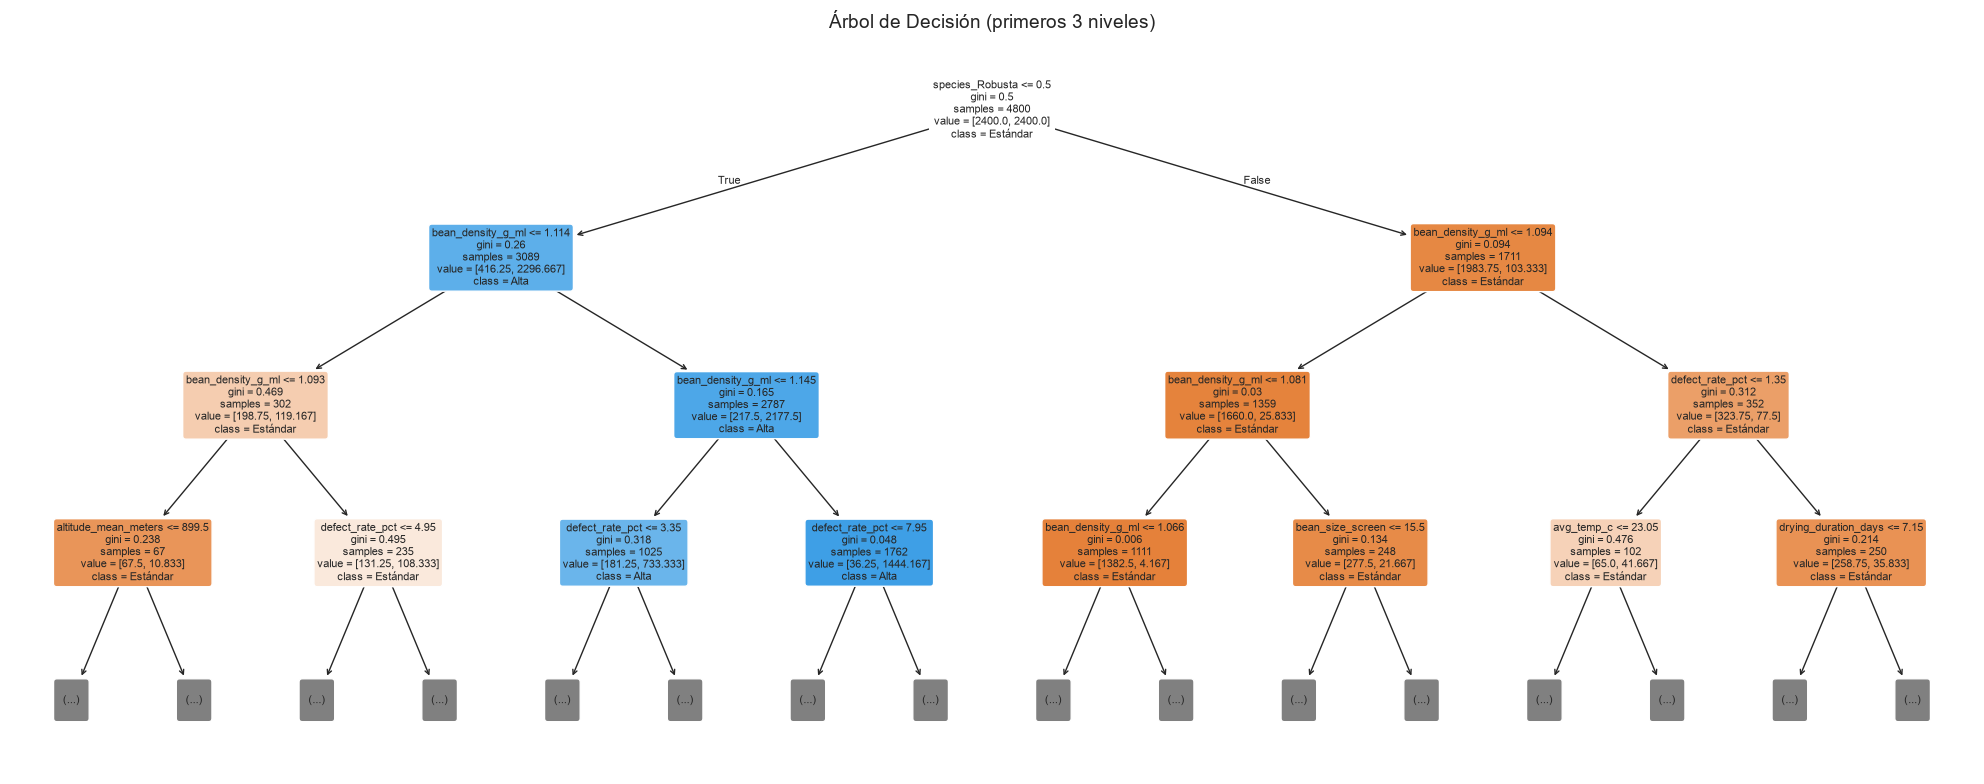

In [21]:
# 6.2  Visualización del árbol
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    pipe_dt.named_steps['clf'],
    feature_names=list(features),
    class_names=['Estándar', 'Alta'],
    filled=True, rounded=True, fontsize=8, ax=ax,
    max_depth=3  # Mostrar solo 3 niveles para legibilidad
)
ax.set_title('Árbol de Decisión (primeros 3 niveles)', fontsize=14)
plt.tight_layout()
plt.show()

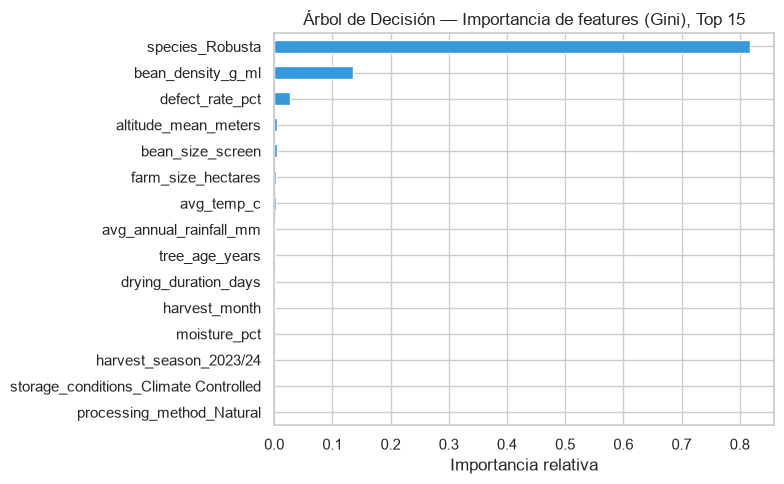

In [22]:
# 6.3  Importancia de features (Gini importance) — Top 15
importances = pd.Series(
    pipe_dt.named_steps['clf'].feature_importances_,
    index=features
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Árbol de Decisión — Importancia de features (Gini), Top 15')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

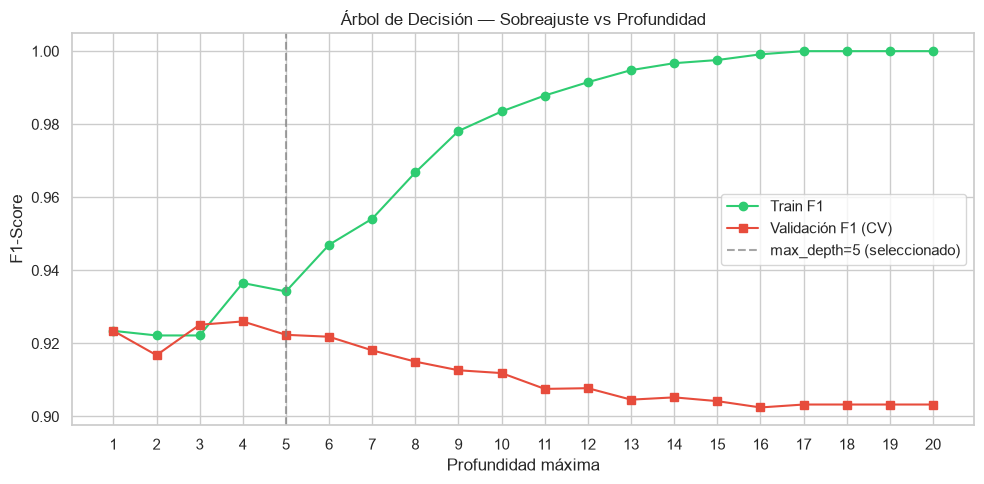

Observación: cuando la brecha entre train y validación crece,
el modelo está sobreajustando (memorizando el train set).


In [23]:
# 6.4  Efecto de la profundidad en sobreajuste/subajuste
depths = range(1, 21)
train_scores = []
val_scores = []

for d in depths:
    dt = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', DecisionTreeClassifier(max_depth=d, class_weight='balanced',
                                       random_state=RANDOM_STATE))
    ])
    dt.fit(X_train, y_train)
    train_scores.append(f1_score(y_train, dt.predict(X_train)))
    cv_s = cross_val_score(dt, X_train, y_train, cv=cv, scoring='f1')
    val_scores.append(cv_s.mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_scores, 'o-', label='Train F1', color='#2ecc71')
ax.plot(depths, val_scores, 's-', label='Validación F1 (CV)', color='#e74c3c')
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.7, label='max_depth=5 (seleccionado)')
ax.set_xlabel('Profundidad máxima')
ax.set_ylabel('F1-Score')
ax.set_title('Árbol de Decisión — Sobreajuste vs Profundidad')
ax.legend()
ax.set_xticks(depths)
plt.tight_layout()
plt.show()

print('Observación: cuando la brecha entre train y validación crece,')
print('el modelo está sobreajustando (memorizando el train set).')

---
## 7. Modelo 3 — Support Vector Machine (SVM)

**Fundamento:** Busca el hiperplano que maximiza el margen de separación entre clases. Con funciones kernel puede manejar fronteras no lineales. Es **sensible a la escala** de las features.

In [24]:
# 7.1  Comparación de kernels
kernels = ['linear', 'rbf', 'poly']
svm_results = {}

for kernel in kernels:
    pipe_svm = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=kernel, class_weight='balanced',
                     random_state=RANDOM_STATE, probability=True))
    ])
    scores = cross_val_score(pipe_svm, X_train, y_train, cv=cv, scoring='f1')
    svm_results[kernel] = scores
    print(f'SVM ({kernel:6s}) — F1 CV: {scores.mean():.4f} ± {scores.std():.4f}')

# Seleccionar el mejor kernel
best_kernel = max(svm_results, key=lambda k: svm_results[k].mean())
print(f'\nMejor kernel: {best_kernel}')

SVM (linear) — F1 CV: 0.9322 ± 0.0090
SVM (rbf   ) — F1 CV: 0.9317 ± 0.0087
SVM (poly  ) — F1 CV: 0.9216 ± 0.0075

Mejor kernel: linear


In [25]:
# 7.2  Entrenamiento con el mejor kernel
pipe_svm = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel=best_kernel, class_weight='balanced',
                 random_state=RANDOM_STATE, probability=True))
])

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)
scores_svm = svm_results[best_kernel]

In [26]:
# 7.3  Impacto de la estandarización en SVM
# SVM SIN estandarizar (solo se imputan los faltantes)
svm_no_scale = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', SVC(kernel=best_kernel, class_weight='balanced',
                 random_state=RANDOM_STATE))
])
scores_no_scale = cross_val_score(svm_no_scale, X_train, y_train, cv=cv, scoring='f1')

print('Impacto de la estandarización en SVM:')
print(f'  CON StandardScaler: F1 = {scores_svm.mean():.4f}')
print(f'  SIN StandardScaler: F1 = {scores_no_scale.mean():.4f}')
print(f'  Diferencia: {(scores_svm.mean() - scores_no_scale.mean())*100:+.2f} puntos porcentuales')
print('\n→ La estandarización es CRÍTICA para modelos basados en distancias.')

Impacto de la estandarización en SVM:
  CON StandardScaler: F1 = 0.9322
  SIN StandardScaler: F1 = 0.9231
  Diferencia: +0.91 puntos porcentuales

→ La estandarización es CRÍTICA para modelos basados en distancias.


---
## 8. Modelo 4 — K-Nearest Neighbors (KNN)

**Fundamento:** Clasifica según la mayoría de votos de los K vecinos más cercanos. No paramétrico, sensible a la escala y a la dimensionalidad. El valor de K controla el trade-off bias-varianza.

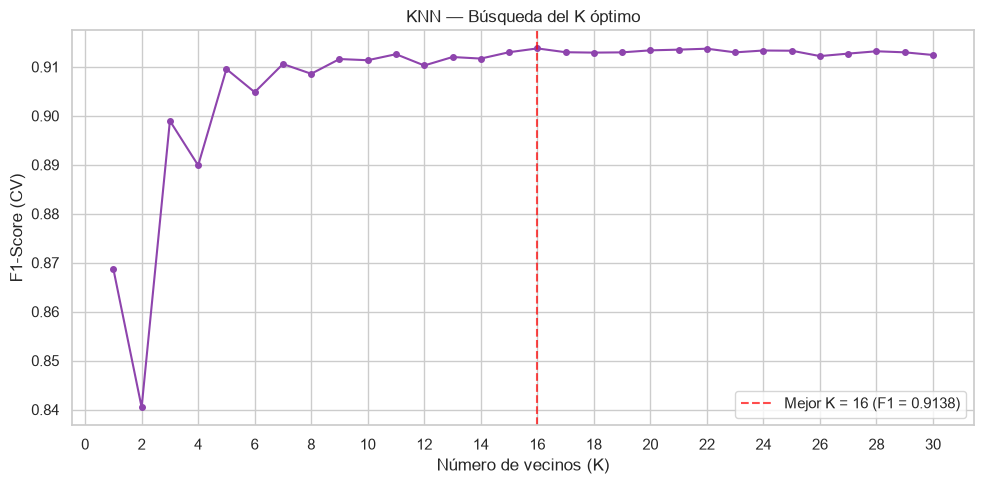

K óptimo: 16


In [27]:
# 8.1  Búsqueda del K óptimo
k_range = range(1, 31)
k_scores = []

for k in k_range:
    pipe_knn = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe_knn, X_train, y_train, cv=cv, scoring='f1')
    k_scores.append(scores.mean())

best_k = k_range[np.argmax(k_scores)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, k_scores, 'o-', markersize=4, color='#8e44ad')
ax.axvline(x=best_k, color='red', linestyle='--', alpha=0.7,
           label=f'Mejor K = {best_k} (F1 = {max(k_scores):.4f})')
ax.set_xlabel('Número de vecinos (K)')
ax.set_ylabel('F1-Score (CV)')
ax.set_title('KNN — Búsqueda del K óptimo')
ax.legend()
ax.set_xticks(range(0, 31, 2))
plt.tight_layout()
plt.show()

print(f'K óptimo: {best_k}')

In [28]:
# 8.2  Entrenamiento con K óptimo
pipe_knn = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=best_k))
])

scores_knn = cross_val_score(pipe_knn, X_train, y_train, cv=cv, scoring='f1')
print(f'KNN (K={best_k}) — F1 CV: {scores_knn.mean():.4f} ± {scores_knn.std():.4f}')

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

KNN (K=16) — F1 CV: 0.9138 ± 0.0070


---
## 9. Análisis comparativo de modelos

In [29]:
# 9.1  Tabla resumen
models = {
    'Logistic Regression': (pipe_lr, y_pred_lr, scores_lr),
    'Decision Tree':       (pipe_dt, y_pred_dt, scores_dt),
    f'SVM ({best_kernel})': (pipe_svm, y_pred_svm, scores_svm),
    f'KNN (K={best_k})':   (pipe_knn, y_pred_knn, scores_knn)
}

summary = []
for name, (pipe, y_pred, cv_scores) in models.items():
    summary.append({
        'Modelo': name,
        'F1 CV (mean)': f'{cv_scores.mean():.4f}',
        'F1 CV (std)': f'{cv_scores.std():.4f}',
        'Accuracy Test': f'{accuracy_score(y_test, y_pred):.4f}',
        'F1 Test': f'{f1_score(y_test, y_pred):.4f}'
    })

summary_df = pd.DataFrame(summary)
print('='*80)
print('COMPARACIÓN DE MODELOS')
print('='*80)
summary_df

COMPARACIÓN DE MODELOS


,Modelo,F1 CV (mean),F1 CV (std),Accuracy Test,F1 Test
0,Logistic Regression,0.9279,0.0066,0.9017,0.9184
1,Decision Tree,0.9248,0.0054,0.8867,0.9033
2,SVM (linear),0.9322,0.0090,0.9033,0.9204
3,KNN (K=16),0.9138,0.0070,0.8858,0.9081


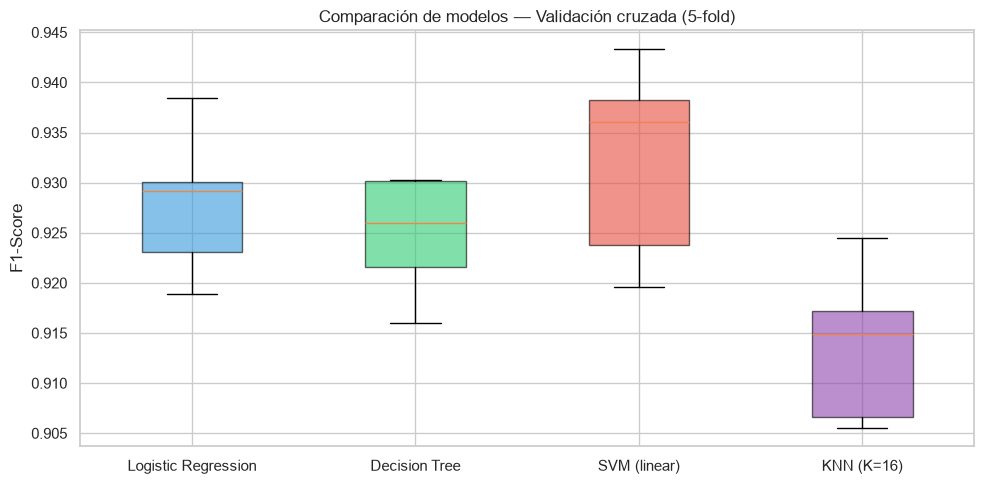

In [30]:
# 9.2  Boxplot comparativo de validación cruzada
fig, ax = plt.subplots(figsize=(10, 5))
cv_data = [scores_lr, scores_dt, scores_svm, scores_knn]
labels = list(models.keys())
bp = ax.boxplot(cv_data, tick_labels=labels, patch_artist=True)
colors_box = ['#3498db', '#2ecc71', '#e74c3c', '#8e44ad']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('F1-Score')
ax.set_title('Comparación de modelos — Validación cruzada (5-fold)')
plt.tight_layout()
plt.show()

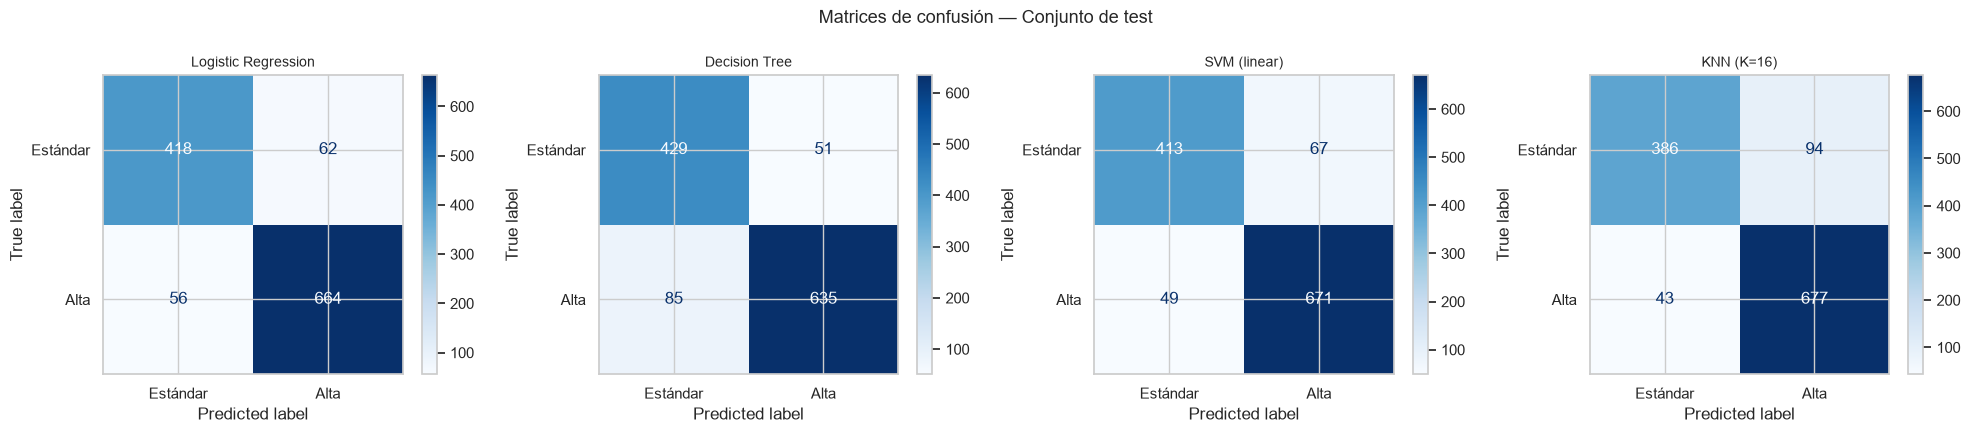

In [31]:
# 9.3  Matrices de confusión comparativas
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, (pipe, y_pred, _)) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Estándar', 'Alta'],
        cmap='Blues', ax=ax
    )
    ax.set_title(name, fontsize=10)

fig.suptitle('Matrices de confusión — Conjunto de test', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

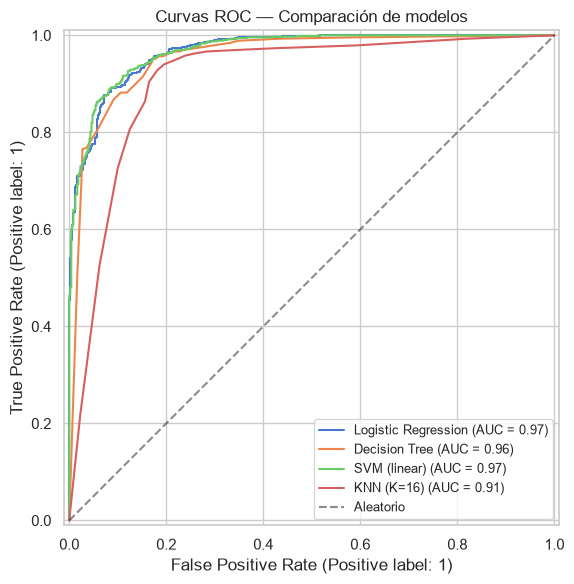

In [32]:
# 9.4  Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(7, 6))

for name, (pipe, _, _) in models.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
ax.set_title('Curvas ROC — Comparación de modelos')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [33]:
# 9.5  Classification report detallado del mejor modelo
best_model_name = max(models, key=lambda k: float(models[k][2].mean()))
best_pipe, best_pred, best_cv = models[best_model_name]

print(f'\nMejor modelo: {best_model_name}')
print('='*60)
print(classification_report(y_test, best_pred,
                             target_names=['Estándar', 'Alta']))


Mejor modelo: SVM (linear)
              precision    recall  f1-score   support

    Estándar       0.89      0.86      0.88       480
        Alta       0.91      0.93      0.92       720

    accuracy                           0.90      1200
   macro avg       0.90      0.90      0.90      1200
weighted avg       0.90      0.90      0.90      1200



---
## 10. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Regresión Logística** | Rápido, interpretable (coeficientes), probabilístico | Asume relación lineal entre features y log-odds | Baseline; cuando la interpretabilidad es prioritaria |
| **Árbol de Decisión** | Interpretable (visualización), maneja no linealidades, no requiere estandarización | Propenso a sobreajuste; inestable (pequeños cambios en datos alteran el árbol) | Cuando se necesitan reglas explicables; como parte de ensambles |
| **SVM** | Efectivo en alta dimensionalidad; flexible con kernels | Sensible a la escala; costoso en datasets grandes; difícil de interpretar | Datasets de tamaño moderado con fronteras complejas |
| **KNN** | Simple, no paramétrico, adaptable | Lento en predicción (distancias contra todo el train); sensible a escala y dimensionalidad | Datasets pequeños-medianos; cuando la frontera es irregular |

---
## 11. Ejercicios propuestos

### Ejercicio 1 — GridSearchCV para SVM
Búsqueda de hiperparámetros para SVM usando `GridSearchCV` con la siguiente grilla:
- `C`: [0.1, 1, 10, 100]
- `gamma`: ['scale', 'auto', 0.01, 0.1]
- `kernel`: ['rbf', 'poly']

Se reportan los mejores hiperparámetros, el F1-score obtenido y la comparación contra el SVM base de la sesión.

In [34]:
# Ejercicio 1 — GridSearchCV para SVM
param_grid = {
    'clf__C': [0.1, 1, 10, 100],
    'clf__gamma': ['scale', 'auto', 0.01, 0.1],
    'clf__kernel': ['rbf', 'poly']
}

pipe_svm_grid = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', SVC(class_weight='balanced', random_state=RANDOM_STATE))
])

grid_svm = GridSearchCV(pipe_svm_grid, param_grid, cv=cv, scoring='f1', n_jobs=-1)
grid_svm.fit(X_train, y_train)

print('Mejores hiperparámetros:')
for k, v in grid_svm.best_params_.items():
    print(f'  {k.replace("clf__", ""):8s}: {v}')
print(f'\nMejor F1 (CV): {grid_svm.best_score_:.4f}')

Mejores hiperparámetros:
  C       : 1
  gamma   : scale
  kernel  : rbf

Mejor F1 (CV): 0.9317


In [35]:
# Comparación: SVM base vs SVM optimizado con GridSearchCV
y_pred_grid = grid_svm.predict(X_test)

comparacion_svm = pd.DataFrame({
    'Modelo': [f'SVM base ({best_kernel}, C=1, gamma=scale)', 'SVM GridSearchCV'],
    'F1 CV': [scores_svm.mean(), grid_svm.best_score_],
    'F1 Test': [f1_score(y_test, y_pred_svm), f1_score(y_test, y_pred_grid)],
    'Accuracy Test': [accuracy_score(y_test, y_pred_svm), accuracy_score(y_test, y_pred_grid)]
}).round(4)

mejora = (comparacion_svm.loc[1, 'F1 Test'] - comparacion_svm.loc[0, 'F1 Test']) * 100
print(f'Cambio en F1 Test tras GridSearchCV: {mejora:+.2f} puntos porcentuales')
comparacion_svm

Cambio en F1 Test tras GridSearchCV: +0.48 puntos porcentuales


,Modelo,F1 CV,F1 Test,Accuracy Test
0,"SVM base (linear, C=1, gamma=scale)",0.9322,0.9204,0.9033
1,SVM GridSearchCV,0.9317,0.9252,0.9083


### Ejercicio 2 — Clasificación multiclase
En lugar de binarizar la calidad, se utilizan las **5 clases originales** (`Commercial`, `Good`, `Very Good`, `Excellent`, `Exceptional`) y se entrenan los 4 modelos. Se analiza:
- ¿Cómo cambia el rendimiento de cada modelo?
- ¿Qué clases son más difíciles de distinguir?
- ¿Qué métrica de F1 es más adecuada: `macro`, `micro` o `weighted`?

In [36]:
# Ejercicio 2 — Clasificación multiclase (5 grados originales)
y_multi = df['quality_grade'].map({g: i for i, g in enumerate(orden)})

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X, y_multi, test_size=0.20, random_state=RANDOM_STATE, stratify=y_multi
)

print('Distribución de clases en train:')
print(ym_train.map(dict(enumerate(orden))).value_counts().reindex(orden))

models_multi = {
    'Logistic Regression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                   class_weight='balanced'))
    ]),
    'Decision Tree': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                       class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    f'SVM ({best_kernel})': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=best_kernel, class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    f'KNN (K={best_k})': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=best_k))
    ])
}

resultados_multi = []
preds_multi = {}
for name, pipe in models_multi.items():
    cv_f1 = cross_val_score(pipe, Xm_train, ym_train, cv=cv, scoring='f1_macro')
    pipe.fit(Xm_train, ym_train)
    pred = pipe.predict(Xm_test)
    preds_multi[name] = pred
    resultados_multi.append({
        'Modelo': name,
        'F1 macro CV': cv_f1.mean(),
        'Accuracy': accuracy_score(ym_test, pred),
        'F1 macro': f1_score(ym_test, pred, average='macro'),
        'F1 micro': f1_score(ym_test, pred, average='micro'),
        'F1 weighted': f1_score(ym_test, pred, average='weighted')
    })

resultados_multi = pd.DataFrame(resultados_multi).set_index('Modelo').round(4)
print('\n=== Resultados multiclase (Test) ===')
resultados_multi

Distribución de clases en train:
quality_grade
Commercial      960
Good            960
Very Good      1680
Excellent       960
Exceptional     240
Name: count, dtype: int64

=== Resultados multiclase (Test) ===


,F1 macro CV,Accuracy,F1 macro,F1 micro,F1 weighted
Modelo,,,,,
Logistic Regression,0.6098,0.6500,0.6327,0.6500,0.6508
Decision Tree,0.5737,0.5817,0.5694,0.5817,0.5829
SVM (linear),0.6290,0.6625,0.6405,0.6625,0.6634
KNN (K=16),0.3658,0.5133,0.3747,0.5133,0.4652


In [37]:
# ¿Cómo cambia el rendimiento respecto a la clasificación binaria?
comparacion_bin_multi = pd.DataFrame({
    'Accuracy binario': [accuracy_score(y_test, y_pred) for _, y_pred, _ in models.values()],
    'Accuracy multiclase': resultados_multi['Accuracy'].values,
    'F1 binario': [f1_score(y_test, y_pred) for _, y_pred, _ in models.values()],
    'F1 macro multiclase': resultados_multi['F1 macro'].values
}, index=list(models.keys())).round(4)

comparacion_bin_multi['Caída Accuracy'] = (comparacion_bin_multi['Accuracy binario'] - comparacion_bin_multi['Accuracy multiclase']).round(4)
comparacion_bin_multi

,Accuracy binario,Accuracy multiclase,F1 binario,F1 macro multiclase,Caída Accuracy
Logistic Regression,0.9017,0.6500,0.9184,0.6327,0.2517
Decision Tree,0.8867,0.5817,0.9033,0.5694,0.3050
SVM (linear),0.9033,0.6625,0.9204,0.6405,0.2408
KNN (K=16),0.8858,0.5133,0.9081,0.3747,0.3725


F1 por clase y modelo (Test):
             Logistic Regression  Decision Tree  SVM (linear)  KNN (K=16)  \
Commercial                 0.816          0.794         0.813       0.694   
Good                       0.560          0.515         0.584       0.266   
Very Good                  0.682          0.572         0.705       0.603   
Excellent                  0.545          0.485         0.548       0.311   
Exceptional                0.561          0.481         0.552       0.000   

             Promedio  
Commercial      0.779  
Good            0.481  
Very Good       0.640  
Excellent       0.472  
Exceptional     0.399  

Clase más difícil:  Exceptional (F1 promedio = 0.399)
Clase más fácil:    Commercial (F1 promedio = 0.779)


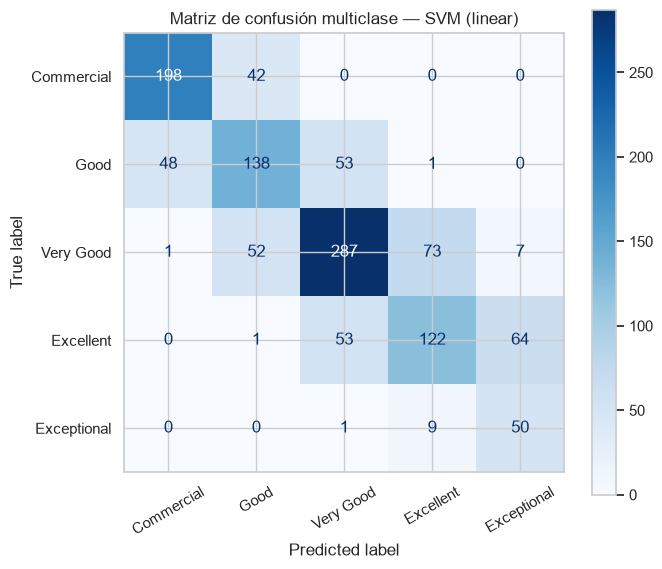

In [38]:
# ¿Qué clases son más difíciles de distinguir? (F1 por clase)
f1_clase = pd.DataFrame(
    {name: f1_score(ym_test, pred, average=None) for name, pred in preds_multi.items()},
    index=orden
)
f1_clase['Promedio'] = f1_clase.mean(axis=1)
print('F1 por clase y modelo (Test):')
print(f1_clase.round(3))

print(f"\nClase más difícil:  {f1_clase['Promedio'].idxmin()} (F1 promedio = {f1_clase['Promedio'].min():.3f})")
print(f"Clase más fácil:    {f1_clase['Promedio'].idxmax()} (F1 promedio = {f1_clase['Promedio'].max():.3f})")

# Matriz de confusión del mejor modelo (según F1 macro)
mejor_multi = resultados_multi['F1 macro'].idxmax()
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    ym_test, preds_multi[mejor_multi],
    display_labels=orden, cmap='Blues', ax=ax, xticks_rotation=30
)
ax.set_title(f'Matriz de confusión multiclase — {mejor_multi}')
plt.tight_layout()
plt.show()

**¿Qué métrica de F1 es más adecuada?**

- **`micro`:** calcula el F1 con los totales de todas las clases; en multiclase de una sola etiqueta equivale al Accuracy y está dominado por las clases grandes.
- **`weighted`:** promedia el F1 de cada clase ponderado por su tamaño; también favorece a las clases mayoritarias.
- **`macro`:** promedia el F1 de las clases con el mismo peso, sin importar su tamaño.

Como las clases están desbalanceadas (`Exceptional` es solo ~5% y `Very Good` ~35%), la métrica más adecuada es **`macro`**: no oculta el mal desempeño en las clases minoritarias.

### Ejercicio 3 — Aplicación con dataset propio
Se aplicó el ciclo completo (secciones 2 a 10) al dataset **Coffee Quality and Pricing Benchmark** con los 4 modelos de clasificación, su análisis comparativo y los ejercicios 1 y 2. Verificación de los requisitos del dataset:

In [39]:
# Ejercicio 3 — Verificación de requisitos del dataset propio
n_registros = df.shape[0]
n_features = len(features_validas)

print(f'Registros usados:           {n_registros}  (mínimo 500)   → {"OK" if n_registros >= 500 else "NO CUMPLE"}')
print(f'Features originales usadas: {n_features}  (mínimo 5)     → {"OK" if n_features >= 5 else "NO CUMPLE"}')
print(f'Features tras codificación: {X.shape[1]}')
print(f'Modelos aplicados:          4 (Regresión Logística, Árbol de Decisión, SVM, KNN)')

Registros usados:           6000  (mínimo 500)   → OK
Features originales usadas: 21  (mínimo 5)     → OK
Features tras codificación: 33
Modelos aplicados:          4 (Regresión Logística, Árbol de Decisión, SVM, KNN)


---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*